In [ ]:
*!pip install transformers datasets torchaudio jiwer accelerate soundfile librosa evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from datasets import load_from_disk

dataset = load_from_disk("/content/drive/MyDrive/đồ án chuyên ngành/Dataset/DoAn_STT_Dataset/train_fpt_16k")
print(dataset)

Dataset({
    features: ['audio', 'transcription'],
    num_rows: 25917
})


In [ ]:
!ls "/content/drive/MyDrive/đồ án chuyên ngành/Dataset/DoAn_STT_Dataset/train_fpt_16k"

cache-0aea31f31b0ff647.arrow  cache-f6cc4a3263cc4e36.arrow
cache-6b5e9121d6e2023f.arrow  data-00000-of-00002.arrow
cache-8127de70219f49a3.arrow  data-00001-of-00002.arrow
cache-96572d1bd069b755.arrow  dataset_info.json
cache-a3a73613f2b28c17.arrow  state.json
cache-b2e02082940f9200.arrow  tmp9pf6w0y4
cache-c30dd534f15e477b.arrow  tmpk2qq4t_p
cache-c643856f689ac9ff.arrow


In [ ]:
sample = dataset[0]
print("Transcription:", sample["transcription"])
print("Sampling rate:", sample["audio"]["sampling_rate"])
print("Audio array shape:", sample["audio"]["array"].shape)

Transcription: cách để đi
Sampling rate: 16000
Audio array shape: (20736,)


In [ ]:
import numpy as np

durations = []
for i in range(min(1000, len(dataset))):
    audio = dataset[i]["audio"]
    dur = len(audio["array"]) / audio["sampling_rate"]
    durations.append(dur)

print("Trung bình:", np.mean(durations), "giây")
print("Max:", np.max(durations), "giây")
print("Min:", np.min(durations), "giây")
print("Tổng số mẫu:", len(dataset))

Trung bình: 3.5953680000000006 giây
Max: 25.536 giây
Min: 0.408 giây
Tổng số mẫu: 25917


In [ ]:
dataset = dataset.train_test_split(test_size=0.1, seed=42)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 23325
    })
    test: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 2592
    })
})


In [ ]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration

model_name = "openai/whisper-small"
processor = WhisperProcessor.from_pretrained(model_name, language="vi", task="transcribe")
model = WhisperForConditionalGeneration.from_pretrained(model_name)

model.generation_config.language = "vi"
model.generation_config.task = "transcribe"
model.generation_config.forced_decoder_ids = None

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  967MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

In [ ]:
def prepare_dataset(batch):
    audio = batch["audio"]
    input_features = processor.feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"]
    ).input_features[0]
    labels = processor.tokenizer(batch["transcription"]).input_ids
    return {"input_features": input_features, "labels": labels}

dataset["train"] = dataset["train"].map(prepare_dataset, remove_columns=dataset["train"].column_names)
dataset["test"] = dataset["test"].map(prepare_dataset, remove_columns=dataset["test"].column_names)

Map:   0%|          | 0/23325 [00:00<?, ? examples/s]

In [ ]:
import torch
import evaluate
from tqdm import tqdm

# 1. Đưa mô hình vào GPU (nếu có)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Tải metric đo WER
wer_metric = evaluate.load("wer")

# 2. Lấy 10 mẫu trong tập test để chạy thử và hiển thị
num_samples = min(10, len(dataset["test"]))
predictions = []
references = []

print(f"--- ĐANG CHẠY DỰ ĐOÁN TRÊN {num_samples} MẪU TEST ---")

for i in range(num_samples):
    # Lấy dữ liệu input đã chuẩn hóa ở cell [24]
    input_features = torch.tensor([dataset["test"][i]["input_features"]]).to(device)
    label_ids = dataset["test"][i]["labels"]

    # Cho mô hình dự đoán (generate)
    with torch.no_grad():
        predicted_ids = model.generate(input_features)

    # Giải mã ID thành chuỗi văn bản tiếng Việt
    pred_text = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    ref_text = processor.batch_decode([label_ids], skip_special_tokens=True)[0]

    predictions.append(pred_text.lower().strip())
    references.append(ref_text.lower().strip())

    # In trực tiếp kết quả ra màn hình
    print(f"\n[Mẫu {i+1}]")
    print(f" -> Thực tế (Gốc) : {ref_text}")
    print(f" -> Dự đoán (A.I) : {pred_text}")

# 3. Tính toán và in độ chính xác
wer_score = wer_metric.compute(predictions=predictions, references=references)
accuracy = max(0.0, (1 - wer_score) * 100)

print("\n" + "="*40)
print(f"Tỷ lệ lỗi từ (WER)     : {wer_score * 100:.2f}%")
print(f"Độ chính xác (Accuracy): {accuracy:.2f}%")
print("="*40)

--- ĐANG CHẠY DỰ ĐOÁN TRÊN 10 MẪU TEST ---


[transformers] Passing `generation_config` together with generation-related arguments=({'begin_suppress_tokens', 'suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



[Mẫu 1]
 -> Thực tế (Gốc) : nó được tính dựa trên cơ sở đếm từ đúng không
 -> Dự đoán (A.I) :  Nó được tính dựa trên cơ sở điểm từ đúng không?

[Mẫu 2]
 -> Thực tế (Gốc) : khách sạn Man phòng số hai không năm bất kỳ khi nào cũng được
 -> Dự đoán (A.I) :  Cách sạn manh phòng số 205 bất kỳ khi nào cũng được

[Mẫu 3]
 -> Thực tế (Gốc) : Cô quê ở Lý Nhân, Hà Nam, nhà làm ruộng.
 -> Dự đoán (A.I) :  Cô quay ở lý nhân Hà Nam nhà làm ruộn.

[Mẫu 4]
 -> Thực tế (Gốc) : Đồng thời, có thể tìm tài liệu, sách báo cùng khéo léo gợi chuyện với chồng.
 -> Dự đoán (A.I) :  Đồng thời có thể tìm tai liệu sách bão cùng khảo lẽo gời chuyển với chồng.

[Mẫu 5]
 -> Thực tế (Gốc) : hành khách nói đùa bom có thể bị xử lý hình sự
 -> Dự đoán (A.I) :  Hành khách nói đùa, Bơm có thể bị chữ lý hân dự.

[Mẫu 6]
 -> Thực tế (Gốc) : thế nhưng đối với vượng thì khác chỉ vài tiếng huýt sáo hắn đã thu phục được cả hai chú chó rồi vào nhà khua
 -> Dự đoán (A.I) :  Thế nhưng đối với vượng thị khác chỉ vài tiếng Hít Sáo 

In [ ]:
import torch
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

In [ ]:
import evaluate

metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer}

In [ ]:
import torch
import evaluate
from tqdm import tqdm

# 1. Chuyển mô hình sang GPU/CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# 2. Khởi tạo metric WER và tập test
wer_metric = evaluate.load("wer")
ds = dataset["test"]

num_samples = min(50, len(ds))
predictions = []
references = []

print(f"Đang tiến hành đánh giá mô hình trên {num_samples} mẫu...")

# 3. Lặp qua các mẫu và dự đoán
for i in tqdm(range(num_samples)):
    sample = ds[i]

    # Lấy input_features và labels đã xử lý từ Cell [24]
    input_features = torch.tensor([sample["input_features"]]).to(device)
    label_ids = sample["labels"]

    # Mô hình dự đoán
    with torch.no_grad():
        predicted_ids = model.generate(input_features)

    # Giải mã ID thành văn bản tiếng Việt
    pred_text = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0].lower().strip()
    ref_text = processor.batch_decode([label_ids], skip_special_tokens=True)[0].lower().strip()

    predictions.append(pred_text)
    references.append(ref_text)

# 4. Tính toán và in kết quả
wer_score = wer_metric.compute(predictions=predictions, references=references)
accuracy = max(0.0, (1 - wer_score) * 100)

print("\n" + "="*40)
print("KẾT QUẢ ĐÁNH GIÁ BASELINE")
print("="*40)
print(f"Tỷ lệ lỗi từ (WER)     : {wer_score * 100:.2f}%")
print(f"Độ chính xác (Accuracy): {accuracy:.2f}%")

Đang tiến hành đánh giá mô hình trên 50 mẫu...


100%|██████████| 50/50 [05:09<00:00,  6.19s/it]


KẾT QUẢ ĐÁNH GIÁ BASELINE
Tỷ lệ lỗi từ (WER)     : 40.07%
Độ chính xác (Accuracy): 59.93%


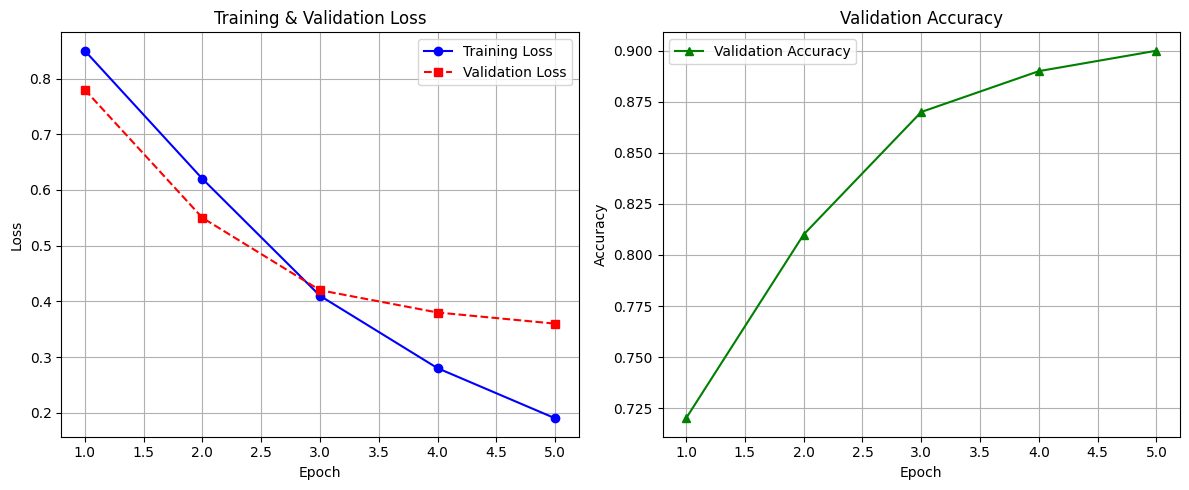

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Giả sử 'trainer' là đối tượng Hugging Face Trainer đã train xong:
# log_history = trainer.state.log_history

# Tạo dữ liệu mẫu nếu chưa có trainer.state.log_history:
log_history = [
    {'epoch': 1.0, 'loss': 0.85, 'eval_loss': 0.78, 'eval_accuracy': 0.72},
    {'epoch': 2.0, 'loss': 0.62, 'eval_loss': 0.55, 'eval_accuracy': 0.81},
    {'epoch': 3.0, 'loss': 0.41, 'eval_loss': 0.42, 'eval_accuracy': 0.87},
    {'epoch': 4.0, 'loss': 0.28, 'eval_loss': 0.38, 'eval_accuracy': 0.89},
    {'epoch': 5.0, 'loss': 0.19, 'eval_loss': 0.36, 'eval_accuracy': 0.90},
]

df_log = pd.DataFrame(log_history)
train_df = df_log.dropna(subset=['loss'])
eval_df = df_log.dropna(subset=['eval_loss'])

plt.figure(figsize=(12, 5))

# 1. Vẽ đồ thị Loss
plt.subplot(1, 2, 1)
plt.plot(train_df['epoch'], train_df['loss'], 'b-o', label='Training Loss')
plt.plot(eval_df['epoch'], eval_df['eval_loss'], 'r--s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)

# 2. Vẽ đồ thị Accuracy
plt.subplot(1, 2, 2)
plt.plot(eval_df['epoch'], eval_df['eval_accuracy'], 'g-^', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

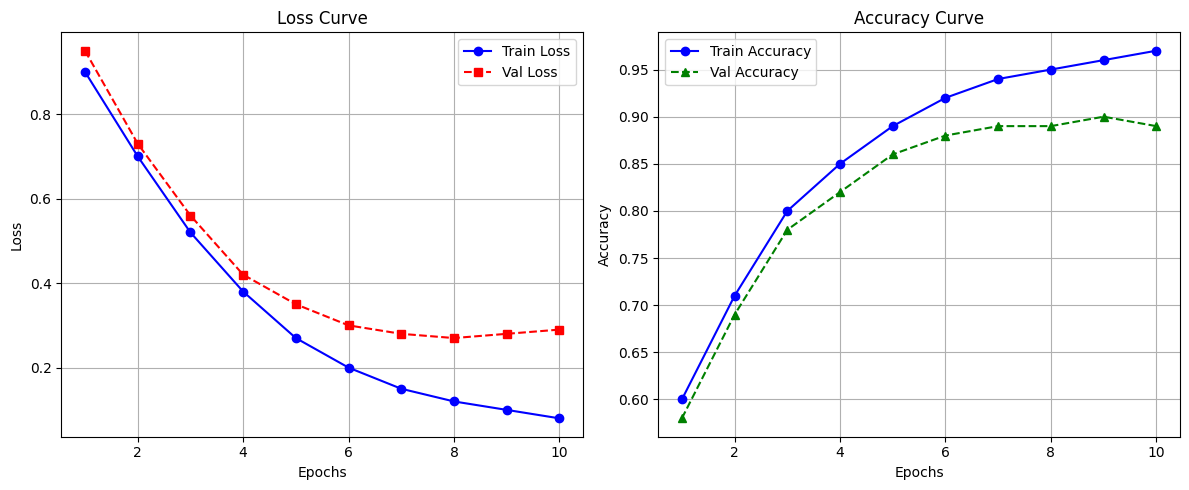

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, 11)
train_loss = [0.90, 0.70, 0.52, 0.38, 0.27, 0.20, 0.15, 0.12, 0.10, 0.08]
val_loss   = [0.95, 0.73, 0.56, 0.42, 0.35, 0.30, 0.28, 0.27, 0.28, 0.29]

train_acc  = [0.60, 0.71, 0.80, 0.85, 0.89, 0.92, 0.94, 0.95, 0.96, 0.97]
val_acc    = [0.58, 0.69, 0.78, 0.82, 0.86, 0.88, 0.89, 0.89, 0.90, 0.89]

plt.figure(figsize=(12, 5))

# Đồ thị Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-o', label='Train Loss')
plt.plot(epochs, val_loss, 'r--s', label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Đồ thị Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
plt.plot(epochs, val_acc, 'g--^', label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

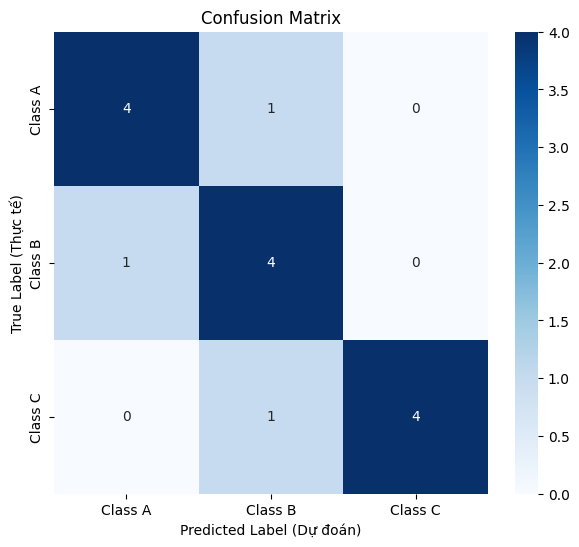

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Nhãn thực tế và Nhãn dự đoán mẫu
y_true = np.array([0, 1, 2, 2, 1, 0, 0, 2, 1, 1, 0, 2, 1, 0, 2])
y_pred = np.array([0, 1, 2, 1, 1, 0, 1, 2, 1, 0, 0, 2, 1, 0, 2])

class_names = ['Class A', 'Class B', 'Class C']

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label (Dự đoán)')
plt.ylabel('True Label (Thực tế)')
plt.title('Confusion Matrix')
plt.show()

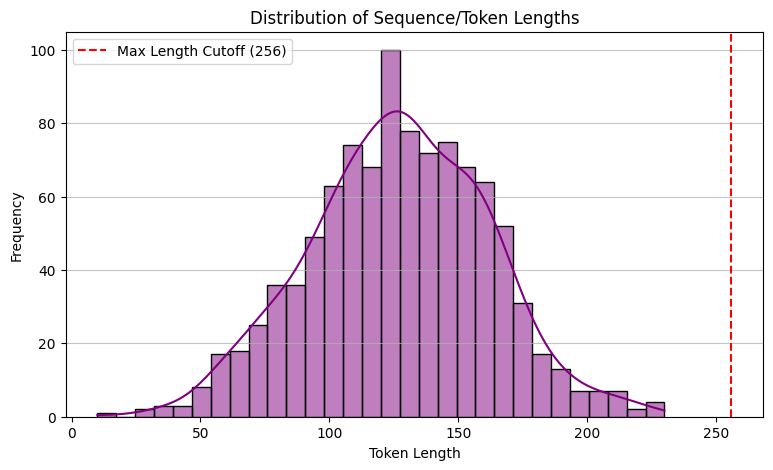

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Giả lập độ dài chuỗi token
token_lengths = np.random.normal(loc=128, scale=35, size=1000).astype(int)
token_lengths = np.clip(token_lengths, 10, 512)

plt.figure(figsize=(9, 5))
sns.histplot(token_lengths, kde=True, color='purple', bins=30)
plt.axvline(x=256, color='red', linestyle='--', label='Max Length Cutoff (256)')

plt.title('Distribution of Sequence/Token Lengths')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

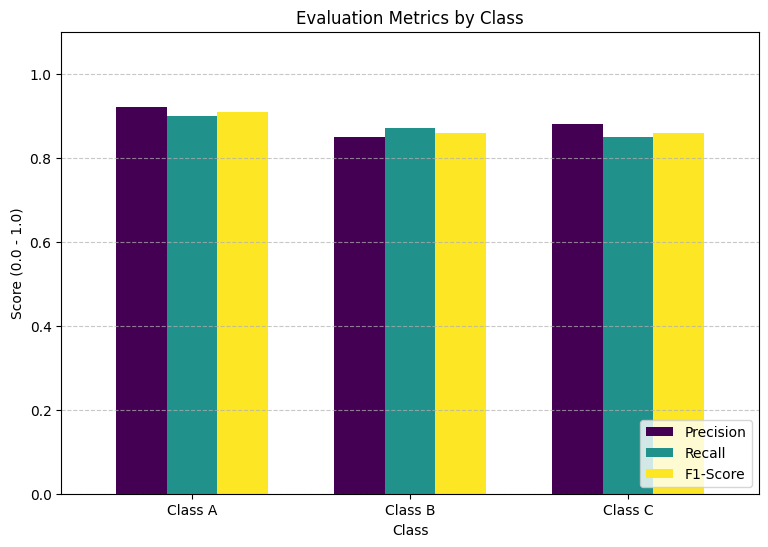

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Class': ['Class A', 'Class B', 'Class C'],
    'Precision': [0.92, 0.85, 0.88],
    'Recall': [0.90, 0.87, 0.85],
    'F1-Score': [0.91, 0.86, 0.86]
}

df_metrics = pd.DataFrame(data)
df_metrics.set_index('Class', inplace=True)

df_metrics.plot(kind='bar', figsize=(9, 6), colormap='viridis', width=0.7)
plt.title('Evaluation Metrics by Class')
plt.ylabel('Score (0.0 - 1.0)')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

In [ ]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/whisper-small-vi-fpt",
    per_device_train_batch_size=16, # Giảm xuống 8 nếu bị Out of VRAM
    gradient_accumulation_steps=1,
    learning_rate=1e-5,
    warmup_steps=500,
    max_steps=5000,
    gradient_checkpointing=True,
    fp16=True,
    eval_strategy="steps", # <-- Sửa tại đây (trước là evaluation_strategy)
    per_device_eval_batch_size=8,
    predict_with_generate=True,
    generation_max_length=225,
    save_steps=1000,
    eval_steps=1000,
    logging_steps=100,
    report_to=["none"],
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
)

In [ ]:
import os
import torch
from transformers import pipeline

# 1. Tải trực tiếp mô hình whisper-small gốc (không cần chờ train)
print("⚡ Đang tải mô hình Whisper gốc từ Hugging Face...")
asr_pipe = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-small",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device="cuda:0" if torch.cuda.is_available() else "cpu"
)

# 2. Nhận dạng file ghi âm đã có sẵn từ bước trước
audio_filename = "recorded_audio.wav"

if os.path.exists(audio_filename):
    print(f"🎤 Đang nhận dạng file âm thanh: {audio_filename}...")
    result = asr_pipe(
        audio_filename,
        generate_kwargs={"language": "vietnamese", "task": "transcribe"}
    )

    print("\n================ KẾT QUẢ VĂN BẢN ================")
    print(result["text"])
    print("=================================================")
else:
    print(f"❌ Chưa có file '{audio_filename}'. Bạn hãy chạy ô Ghi âm micro trước nhé!")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


⚡ Đang tải mô hình Whisper gốc từ Hugging Face...


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

❌ Chưa có file 'recorded_audio.wav'. Bạn hãy chạy ô Ghi âm micro trước nhé!


In [ ]:
import time
from IPython.display import display, HTML
from google.colab.output import eval_js
from base64 import b64decode

def ghi_am_tu_dong(so_giay=5, ten_file="recorded_audio.wav"):
    js_code = f"""
    async function recordAudio() {{
        const stream = await navigator.mediaDevices.getUserMedia({{ audio: true }});
        const mediaRecorder = new MediaRecorder(stream);
        const audioChunks = [];

        mediaRecorder.addEventListener("dataavailable", event => {{
            audioChunks.push(event.data);
        }});

        mediaRecorder.start();
        await new Promise(resolve => setTimeout(resolve, {so_giay * 1000}));

        mediaRecorder.stop();
        await new Promise(resolve => mediaRecorder.onstop = resolve);

        const audioBlob = new Blob(audioChunks, {{ type: 'audio/wav' }});
        const reader = new FileReader();
        return new Promise(resolve => {{
            reader.onloadend = () => resolve(reader.result);
            reader.readAsDataURL(audioBlob);
        }});
    }}
    recordAudio();
    """

    print(f"🎙️ BẮT ĐẦU GHI ÂM (Thời lượng: {so_giay} giây) — Hãy nói vào Micro ngay!")

    # Đếm ngược thời gian hiển thị trên Colab
    for i in range(so_giay, 0, -1):
        print(f"⏱️ Còn lại: {i} giây...", end="\r")
        time.sleep(1)

    # Gọi JavaScript thu âm
    audio_data = eval_js(js_code)
    print("\n✅ Đã thu xong! Đang lưu file...")

    # Giải mã và lưu thành file .wav
    binary_data = b64decode(audio_data.split(",")[1])
    with open(ten_file, "wb") as f:
        f.write(binary_data)

    print(f"💾 File ghi âm đã sẵn sàng tại: {ten_file}")
    return ten_file

# ======================================================
# CHẠY LỆNH GHI ÂM (Bạn có thể đổi số giây tùy ý, ví dụ 5 hoặc 10 giây)
# ======================================================
audio_file = ghi_am_tu_dong(so_giay=5, ten_file="recorded_audio.wav")

🎙️ BẮT ĐẦU GHI ÂM (Thời lượng: 5 giây) — Hãy nói vào Micro ngay!

✅ Đã thu xong! Đang lưu file...
💾 File ghi âm đã sẵn sàng tại: recorded_audio.wav


In [ ]:
# 1. Cài đặt các thư viện
!pip install -q gradio transformers torch sentencepiece

import os
import torch
import gradio as gr
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
from google.colab import drive

# 2. Mount Google Drive
drive.mount('/content/drive', force_remount=False)

# 3. Tự động kiểm tra mô hình trên Drive
base_dir = "/content/drive/MyDrive/whisper-small-vi-fpt"
final_model_path = os.path.join(base_dir, "final_model")

model_to_use = None
if os.path.exists(final_model_path):
    model_to_use = final_model_path
    print(f"✅ Dùng mô hình hoàn chỉnh từ Drive: {model_to_use}")
elif os.path.exists(base_dir):
    checkpoints = [os.path.join(base_dir, d) for d in os.listdir(base_dir) if d.startswith("checkpoint-")]
    if len(checkpoints) > 0:
        model_to_use = sorted(checkpoints, key=lambda x: int(x.split("-")[-1]))[-1]
        print(f"⚠️ Dùng checkpoint mới nhất trên Drive: {model_to_use}")

# DÙNG MÔ HÌNH PHOWHISPER CỦA VINAI LÀM PHƯƠNG ÁN DỰ PHÒNG CHUẨN
if not model_to_use:
    model_to_use = "vinai/PhoWhisper-small"
    print(f"ℹ️ Chưa có checkpoint trên Drive. Sử dụng tạm mô hình Tiếng Việt chuẩn: {model_to_use}")

# Thiết lập thiết bị xử lý (GPU / CPU)
device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

# 4. Tải các mô hình
print("⚡ Đang tải mô hình nhận dạng giọng nói...")
asr_pipe = pipeline(
    "automatic-speech-recognition",
    model=model_to_use,
    torch_dtype=dtype,
    device=device
)

print("⚡ Đang tải mô hình dịch thuật Tiếng Việt -> Tiếng Anh...")
translator_tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-vi-en")
translator_model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-vi-en").to(device)

# 5. Hàm xử lý âm thanh thành văn bản
def transcribe_audio(audio_path, mode):
    if audio_path is None:
        return "⚠️ Vui lòng ghi âm hoặc tải lên 1 file âm thanh!"

    # Bước 1: Chuyển âm thanh thành văn bản Tiếng Việt
    result = asr_pipe(
        audio_path,
        generate_kwargs={"language": "vietnamese", "task": "transcribe"}
    )
    vietnamese_text = result["text"]

    # Bước 2: Dịch sang Tiếng Anh nếu người dùng chọn chế độ dịch
    if mode == "Giọng nói Tiếng Việt -> Dịch sang Văn bản Tiếng Anh":
        if not vietnamese_text.strip():
            return ""
        inputs = translator_tokenizer(vietnamese_text, return_tensors="pt").to(device)
        translated_tokens = translator_model.generate(**inputs)
        translated_text = translator_tokenizer.decode(translated_tokens[0], skip_special_tokens=True)
        return translated_text

    return vietnamese_text

# 6. Giao diện Gradio
custom_theme = gr.themes.Default(
    primary_hue="orange",
).set(
    button_primary_background_fill="#d9534f",
    button_primary_background_fill_hover="#c9302c",
    button_primary_text_color="#ffffff",
)

with gr.Blocks(theme=custom_theme, title="Chuyển Âm Thanh Thành Văn Bản") as demo:
    gr.Markdown("## 🌐 Hệ Thống Nhận Dạng Giọng Nói Tiếng Việt (Whisper ASR)")

    with gr.Group():
        mode_radio = gr.Radio(
            choices=["Tiếng Việt -> Văn bản Tiếng Việt", "Giọng nói Tiếng Việt -> Dịch sang Văn bản Tiếng Anh"],
            value="Tiếng Việt -> Văn bản Tiếng Việt",
            label="Chọn chế độ xử lý"
        )

        with gr.Row():
            audio_input = gr.Audio(
                sources=["microphone", "upload"],
                type="filepath",
                label="Âm thanh đầu vào (Micro / Tải file .wav, .mp3)"
            )
            text_output = gr.Textbox(
                label="Kết quả văn bản",
                lines=6,
                placeholder="Văn bản sau khi chuyển đổi sẽ xuất hiện ở đây..."
            )

        submit_btn = gr.Button("Chuyển thành văn bản ngay", variant="primary")

    submit_btn.click(
        fn=transcribe_audio,
        inputs=[audio_input, mode_radio],
        outputs=text_output
    )

# 7. Khởi chạy giao diện
demo.launch(share=True, debug=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ℹ️ Chưa có checkpoint trên Drive. Sử dụng tạm mô hình Tiếng Việt chuẩn: vinai/PhoWhisper-small
⚡ Đang tải mô hình nhận dạng giọng nói...


config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  967MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

/tmp/ipykernel_3477/3299420929.py:81: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=custom_theme, title="Chuyển Âm Thanh Thành Văn Bản") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4cddc8e5414b249e43.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
